# GraphSAGE Pipeline - Train on WelFake (44k) and Infer on FakeNews (3k)

Notebook nay huan luyen GraphSAGE tren tap WelFake voi 44,000 mau,
sau do thuc hien cross-dataset inference tren 3,000 mau FakeNews (fake.csv + true.csv).

---
## Cell 0 - Imports and Setup

In [1]:
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.sparse import csr_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.nn import SAGEConv
from torch_geometric.data import Data

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

c:\Users\MINH\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.4.1+cpu
CUDA available: False
Device: cpu


In [2]:
# Auto-detect project root
cwd = Path('.').resolve()
PROJECT_ROOT = cwd
for _ in range(5):
    if (PROJECT_ROOT / 'data').exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
CKPT_DIR = PROJECT_ROOT / 'output' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

WELFAKE_PATH = RAW_DIR / 'WELFake_Dataset.csv'
FAKE_PATH = RAW_DIR / 'fake.csv'
TRUE_PATH = RAW_DIR / 'true.csv'
CHECKPOINT_SAGE = CKPT_DIR / 'sage_welfake.pt'

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"WELFake CSV : {WELFAKE_PATH} (exists={WELFAKE_PATH.exists()})")
print(f"fake.csv    : {FAKE_PATH} (exists={FAKE_PATH.exists()})")
print(f"true.csv    : {TRUE_PATH} (exists={TRUE_PATH.exists()})")
print(f"Checkpoint  : {CHECKPOINT_SAGE}")

if not WELFAKE_PATH.exists():
    raise FileNotFoundError(f"WELFake_Dataset.csv not found in {RAW_DIR}")
if not FAKE_PATH.exists() or not TRUE_PATH.exists():
    raise FileNotFoundError(f"fake.csv/true.csv not found in {RAW_DIR}")

PROJECT_ROOT: D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN
WELFake CSV : D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN\data\raw\WELFake_Dataset.csv (exists=True)
fake.csv    : D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN\data\raw\fake.csv (exists=True)
true.csv    : D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN\data\raw\true.csv (exists=True)
Checkpoint  : D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN\output\checkpoints\sage_welfake.pt


In [3]:
# Hyperparameters
WELFAKE_TRAIN_SIZE = 44000   # Train size on WelFake
FAKENEWS_INFER_SIZE = 3000   # Inference size on FakeNews
MAX_FEATURES = 2000
KNN_K = 5
TEST_RATIO = 0.2
RANDOM_SEED = 42

SAGE_HIDDEN = 256
SAGE_DROPOUT = 0.5
EPOCHS = 120
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 5e-4

print('Configuration:')
print(f'  WELFAKE_TRAIN_SIZE = {WELFAKE_TRAIN_SIZE}')
print(f'  FAKENEWS_INFER_SIZE = {FAKENEWS_INFER_SIZE}')
print(f'  MAX_FEATURES = {MAX_FEATURES}')
print(f'  KNN_K = {KNN_K}')
print(f'  EPOCHS = {EPOCHS}')
print(f'  LEARNING_RATE = {LEARNING_RATE}')

Configuration:
  WELFAKE_TRAIN_SIZE = 44000
  FAKENEWS_INFER_SIZE = 3000
  MAX_FEATURES = 2000
  KNN_K = 5
  EPOCHS = 120
  LEARNING_RATE = 0.0005


---
## Cell 1 - Load and Preprocess WelFake

In [4]:
def preprocess_text(text: str) -> str:
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return ' '.join(text.split())

print('=' * 60)
print('STEP 1: Loading WelFake')
print('=' * 60)

wf_df = pd.read_csv(WELFAKE_PATH)
wf_df = wf_df.dropna(subset=['title', 'text', 'label']).reset_index(drop=True)
print(f'  Total after dropna: {len(wf_df):,}')

wf_df['title'] = wf_df['title'].astype(str).apply(preprocess_text)
wf_df['text'] = wf_df['text'].astype(str).apply(preprocess_text)
wf_df['content'] = wf_df['title'] + ' ' + wf_df['text']
wf_df['label'] = wf_df['label'].astype(int)

wf_size = min(WELFAKE_TRAIN_SIZE, len(wf_df))
wf_sample = wf_df.sample(n=wf_size, random_state=RANDOM_SEED).reset_index(drop=True)
y_wf = wf_sample['label'].values

real_count = int((y_wf == 0).sum())
fake_count = int((y_wf == 1).sum())
print(f'  Sampled: {len(wf_sample):,}')
print(f'  Real: {real_count} ({real_count/len(y_wf)*100:.1f}%)')
print(f'  Fake: {fake_count} ({fake_count/len(y_wf)*100:.1f}%)')

STEP 1: Loading WelFake
  Total after dropna: 71,537
  Sampled: 44,000
  Real: 21534 (48.9%)
  Fake: 22466 (51.1%)


---
## Cell 2 - Build TF-IDF and KNN Graph

In [5]:
def build_knn_edge_index(features: np.ndarray, k: int):
    nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='auto', metric='cosine')
    nbrs.fit(features)
    _, indices = nbrs.kneighbors(features)

    rows, cols = [], []
    for i in range(features.shape[0]):
        for j in range(1, k + 1):
            rows.append(i)
            cols.append(indices[i][j])

    adjacency = csr_matrix((np.ones(len(rows)), (rows, cols)),
                          shape=(features.shape[0], features.shape[0]))
    adjacency = adjacency.maximum(adjacency.transpose())
    coo = adjacency.tocoo()
    edge_index = torch.tensor(np.array([coo.row, coo.col]), dtype=torch.long)
    return edge_index, adjacency

print('=' * 60)
print('STEP 2: TF-IDF + KNN graph (WelFake)')
print('=' * 60)

vectorizer = TfidfVectorizer(max_features=MAX_FEATURES)
wf_tfidf = vectorizer.fit_transform(wf_sample['content']).toarray()
scaler = StandardScaler()
wf_x = scaler.fit_transform(wf_tfidf)

edge_index_wf, adjacency_wf = build_knn_edge_index(wf_x, KNN_K)

print(f'  Feature shape: {wf_x.shape}')
print(f'  Nodes: {adjacency_wf.shape[0]:,}')
print(f'  Edges: {adjacency_wf.count_nonzero():,}')
print(f'  Avg degree: {adjacency_wf.count_nonzero() / adjacency_wf.shape[0]:.2f}')

STEP 2: TF-IDF + KNN graph (WelFake)
  Feature shape: (44000, 2000)
  Nodes: 44,000
  Edges: 365,927
  Avg degree: 8.32


In [6]:
X_wf_tensor = torch.tensor(wf_x, dtype=torch.float32)
y_wf_tensor = torch.tensor(y_wf, dtype=torch.long)

data_wf = Data(x=X_wf_tensor, edge_index=edge_index_wf, y=y_wf_tensor)

idx = np.arange(len(y_wf))
idx_train, idx_test = train_test_split(
    idx,
    test_size=TEST_RATIO,
    random_state=RANDOM_SEED,
    stratify=y_wf
)

train_mask = torch.zeros(len(y_wf), dtype=torch.bool)
test_mask = torch.zeros(len(y_wf), dtype=torch.bool)
train_mask[idx_train] = True
test_mask[idx_test] = True

data_wf.train_mask = train_mask
data_wf.test_mask = test_mask
data_wf = data_wf.to(DEVICE)

print(f'Train samples: {train_mask.sum().item():,}')
print(f'Test samples : {test_mask.sum().item():,}')

Train samples: 35,200
Test samples : 8,800


---
## Cell 3 - GraphSAGE Model and Training

In [7]:
class SAGEModel(nn.Module):
    def __init__(self, in_channels, hidden_channels=256, out_channels=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)

model_sage = SAGEModel(
    in_channels=MAX_FEATURES,
    hidden_channels=SAGE_HIDDEN,
    out_channels=2,
    dropout=SAGE_DROPOUT
).to(DEVICE)

n_params = sum(p.numel() for p in model_sage.parameters() if p.requires_grad)
print(model_sage)
print(f'Trainable parameters: {n_params:,}')

SAGEModel(
  (conv1): SAGEConv(2000, 256, aggr=mean)
  (conv2): SAGEConv(256, 2, aggr=mean)
)
Trainable parameters: 1,025,282


In [8]:
print('=' * 60)
print('STEP 3: Training GraphSAGE on WelFake')
print('=' * 60)

optimizer = optim.Adam(model_sage.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.CrossEntropyLoss()

train_losses, train_accs, test_accs = [], [], []
start_time = datetime.now()

for epoch in range(EPOCHS):
    model_sage.train()
    optimizer.zero_grad()
    out = model_sage(data_wf)
    loss = loss_fn(out[data_wf.train_mask], data_wf.y[data_wf.train_mask])
    loss.backward()
    optimizer.step()

    model_sage.eval()
    with torch.no_grad():
        out_eval = model_sage(data_wf)
        tr_acc = (out_eval[data_wf.train_mask].argmax(1) == data_wf.y[data_wf.train_mask]).float().mean().item()
        te_acc = (out_eval[data_wf.test_mask].argmax(1) == data_wf.y[data_wf.test_mask]).float().mean().item()

    train_losses.append(loss.item())
    train_accs.append(tr_acc)
    test_accs.append(te_acc)

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f'Epoch {epoch:3d}/{EPOCHS} | Loss={loss.item():.4f} | Train={tr_acc:.4f} | Test={te_acc:.4f}')

elapsed = (datetime.now() - start_time).total_seconds()
print(f'Training finished in {elapsed:.1f}s')

STEP 3: Training GraphSAGE on WelFake
Epoch   0/120 | Loss=0.7307 | Train=0.7734 | Test=0.7726
Epoch  10/120 | Loss=0.2898 | Train=0.8866 | Test=0.8744
Epoch  20/120 | Loss=0.1975 | Train=0.9328 | Test=0.9077
Epoch  30/120 | Loss=0.1429 | Train=0.9578 | Test=0.9220
Epoch  40/120 | Loss=0.1033 | Train=0.9736 | Test=0.9293
Epoch  50/120 | Loss=0.0754 | Train=0.9861 | Test=0.9336
Epoch  60/120 | Loss=0.0552 | Train=0.9934 | Test=0.9374
Epoch  70/120 | Loss=0.0410 | Train=0.9971 | Test=0.9394
Epoch  80/120 | Loss=0.0309 | Train=0.9986 | Test=0.9405
Epoch  90/120 | Loss=0.0242 | Train=0.9993 | Test=0.9419
Epoch 100/120 | Loss=0.0200 | Train=0.9996 | Test=0.9419
Epoch 110/120 | Loss=0.0170 | Train=0.9997 | Test=0.9433
Epoch 119/120 | Loss=0.0147 | Train=0.9998 | Test=0.9434
Training finished in 245.9s


WelFake test accuracy: 0.9434 (94.34%)
              precision    recall  f1-score   support

    Real (0)       0.95      0.93      0.94      4307
    Fake (1)       0.94      0.95      0.95      4493

    accuracy                           0.94      8800
   macro avg       0.94      0.94      0.94      8800
weighted avg       0.94      0.94      0.94      8800



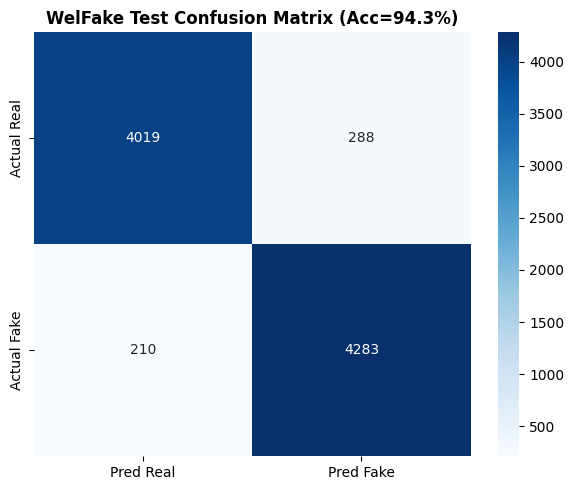

In [9]:
model_sage.eval()
with torch.no_grad():
    out_test = model_sage(data_wf)
    pred_test = out_test[data_wf.test_mask].argmax(dim=1).cpu().numpy()
    y_test = data_wf.y[data_wf.test_mask].cpu().numpy()

wf_test_acc = accuracy_score(y_test, pred_test)
print(f'WelFake test accuracy: {wf_test_acc:.4f} ({wf_test_acc*100:.2f}%)')
print(classification_report(y_test, pred_test, target_names=['Real (0)', 'Fake (1)']))

cm = confusion_matrix(y_test, pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title(f'WelFake Test Confusion Matrix (Acc={wf_test_acc*100:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
checkpoint = {
    'model_state_dict': model_sage.state_dict(),
    'in_channels': MAX_FEATURES,
    'hidden_channels': SAGE_HIDDEN,
    'out_channels': 2,
    'dropout': SAGE_DROPOUT,
    'test_accuracy_welfake': float(wf_test_acc),
    'timestamp': datetime.now().isoformat(),
    'hyperparams': {
        'welfake_train_size': WELFAKE_TRAIN_SIZE,
        'fakenews_infer_size': FAKENEWS_INFER_SIZE,
        'max_features': MAX_FEATURES,
        'knn_k': KNN_K,
        'epochs': EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY
    }
}

torch.save(checkpoint, CHECKPOINT_SAGE)
print(f'Saved checkpoint: {CHECKPOINT_SAGE}')
print(f'Size: {CHECKPOINT_SAGE.stat().st_size / 1024:.1f} KB')

Saved checkpoint: D:\code_vs\Python\Semester_6\Graph_Mining\Fake-News-Detection-GNN\output\checkpoints\sage_welfake.pt
Size: 4008.2 KB


---
## Cell 4 - Cross-Dataset Inference on FakeNews (3000 samples)

Luu y: buoc nay dung chinh vectorizer + scaler da fit tren WelFake
de giu nguyen khong gian dac trung khi infer cross-dataset.

In [11]:
print('=' * 60)
print('STEP 4: Prepare FakeNews for inference')
print('=' * 60)

fake_df = pd.read_csv(FAKE_PATH)
fake_df['label'] = 1
true_df = pd.read_csv(TRUE_PATH)
true_df['label'] = 0

fn_df = pd.concat([fake_df, true_df], ignore_index=True)
fn_df = fn_df.dropna(subset=['title', 'text', 'label']).reset_index(drop=True)

fn_df['title'] = fn_df['title'].astype(str).apply(preprocess_text)
fn_df['text'] = fn_df['text'].astype(str).apply(preprocess_text)
fn_df['content'] = fn_df['title'] + ' ' + fn_df['text']
fn_df['label'] = fn_df['label'].astype(int)

infer_size = min(FAKENEWS_INFER_SIZE, len(fn_df))
fn_sample = fn_df.sample(n=infer_size, random_state=RANDOM_SEED).reset_index(drop=True)
y_fn = fn_sample['label'].values

print(f'  FakeNews samples for inference: {len(fn_sample):,}')
print(f'  Real: {(y_fn == 0).sum():,} | Fake: {(y_fn == 1).sum():,}')

STEP 4: Prepare FakeNews for inference
  FakeNews samples for inference: 3,000
  Real: 1,397 | Fake: 1,603


STEP 5: GraphSAGE inference on FakeNews
Cross-dataset accuracy (WelFake -> FakeNews): 0.9790 (97.90%)
              precision    recall  f1-score   support

    Real (0)       0.97      0.99      0.98      1397
    Fake (1)       0.99      0.97      0.98      1603

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



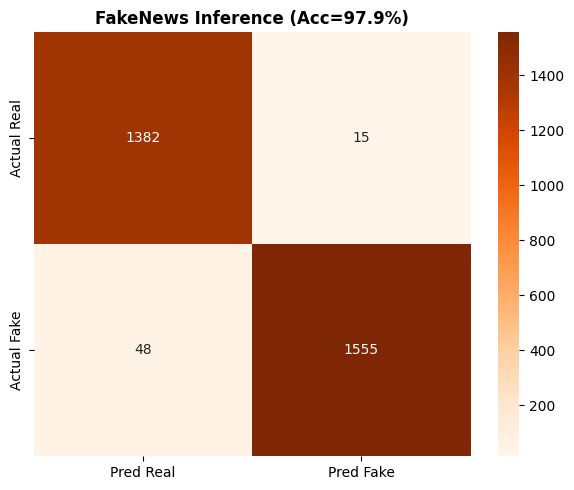

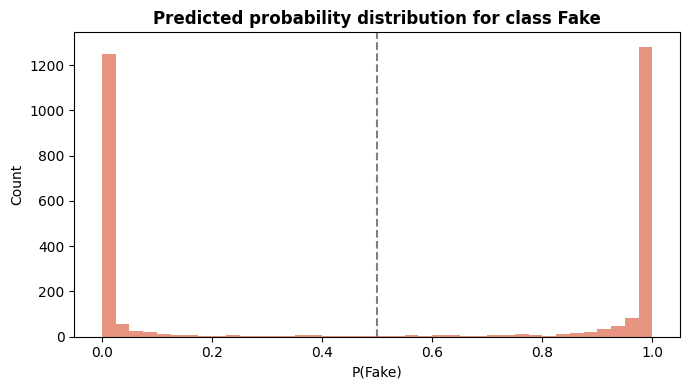

Nodes (FakeNews graph): 3,000
Edges (FakeNews graph): 21,818


In [12]:
print('=' * 60)
print('STEP 5: GraphSAGE inference on FakeNews')
print('=' * 60)

fn_tfidf = vectorizer.transform(fn_sample['content']).toarray()
fn_x = scaler.transform(fn_tfidf)

edge_index_fn, adjacency_fn = build_knn_edge_index(fn_x, KNN_K)

fn_data = Data(
    x=torch.tensor(fn_x, dtype=torch.float32).to(DEVICE),
    edge_index=edge_index_fn.to(DEVICE),
    y=torch.tensor(y_fn, dtype=torch.long).to(DEVICE)
)

model_sage.eval()
with torch.no_grad():
    out_fn = model_sage(fn_data)
    pred_fn = out_fn.argmax(dim=1).cpu().numpy()
    prob_fn = torch.softmax(out_fn, dim=1).cpu().numpy()

fn_acc = accuracy_score(y_fn, pred_fn)
print(f'Cross-dataset accuracy (WelFake -> FakeNews): {fn_acc:.4f} ({fn_acc*100:.2f}%)')
print(classification_report(y_fn, pred_fn, target_names=['Real (0)', 'Fake (1)']))

cm_fn = confusion_matrix(y_fn, pred_fn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_fn, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title(f'FakeNews Inference (Acc={fn_acc*100:.1f}%)', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(prob_fn[:, 1], bins=40, color='#E07A5F', alpha=0.8)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1.5)
plt.title('Predicted probability distribution for class Fake', fontweight='bold')
plt.xlabel('P(Fake)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f'Nodes (FakeNews graph): {adjacency_fn.shape[0]:,}')
print(f'Edges (FakeNews graph): {adjacency_fn.count_nonzero():,}')